In [20]:
import numpy as np 
import matplotlib.pyplot as plt # %%[jupynvim:cell-sep]
import seaborn as sns
# %%[jupynvim:cell-sep]data = np.load("results_sweep.npz")

### Misspecification where the target is undersampled to 10% of the source size, across various proportions of $f_1$.

In [21]:
data = np.load("results_sweep_mixture_checked.npz") # %%[jupynvim:cell-sep]

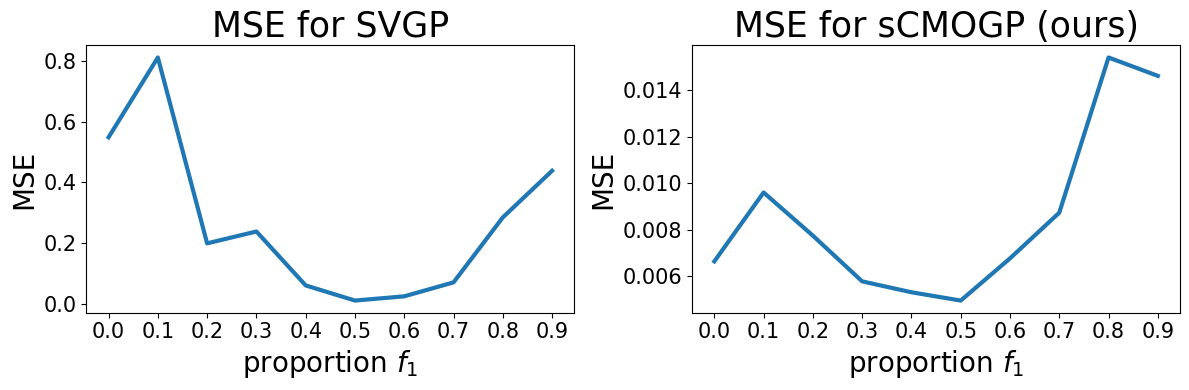

In [22]:
svgp_results = data["svgp"]
cmogp_results = data["cmogp"]
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(svgp_results.mean(axis=1), linewidth=3)
ax[1].plot(cmogp_results.mean(axis=1), linewidth=3)
ax[0].set_xlabel("proportion $f_1$", fontsize=20)
ax[1].set_xlabel("proportion $f_1$", fontsize=20)
ax[0].set_ylabel("MSE", fontsize=20)
ax[1].set_ylabel("MSE", fontsize=20)
ax[0].set_xticks( np.arange(0, 10, 1), np.arange(0, 1, 0.1).round(2), fontsize=15)
ax[1].set_xticks(np.arange(0, 10, 1), np.arange(0, 1, 0.1).round(2), fontsize=15)
ax[0].tick_params(axis='both', which='major', labelsize=15)
ax[1].tick_params(axis='both', which='major', labelsize=15)
ax[0].set_title("MSE for SVGP", fontsize=25)
ax[1].set_title("MSE for sCMOGP (ours)", fontsize=25)
plt.tight_layout()
plt.show()

In [23]:
from scipy.stats import ttest_rel, wilcoxon, normaltest
print(normaltest(cmogp_results.mean(axis=1)))
print(normaltest(svgp_results.mean(axis=1)))

print([np.format_float_positional(p) for p in ttest_rel(cmogp_results, svgp_results, axis=1).pvalue.flatten()])

NormaltestResult(statistic=3.0536847632369315, pvalue=0.21722048494675042)
NormaltestResult(statistic=2.8221567103559204, pvalue=0.24388015187986853)
['0.01695984344878821', '0.022970798865046355', '0.004917407641810968', '0.03702296264496935', '0.009108707626322172', '0.0000940782530611609', '0.0053152721683880156', '0.002300888393936122', '0.003641628711929249', '0.06687598103387743']


/home/janneke/miniforge3/envs/dev/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)


### Misspecification where the target is not undersampled, across different proportions of $f_1$.

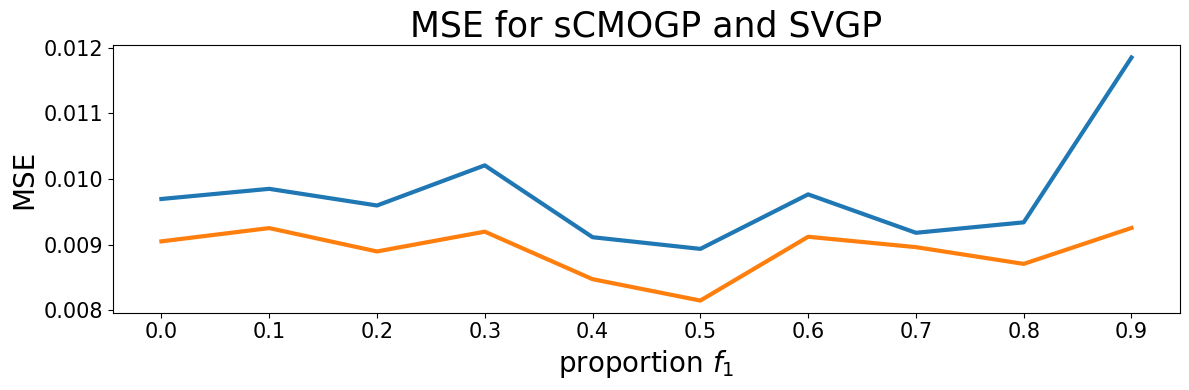

In [29]:
data = np.load("results_at_home_matern32.npz") # %%[jupynvim:cell-sep]
svgp_results = data["svgp"]
cmogp_results = data["cmogp"]
fig, ax = plt.subplots(1, 1, figsize=(12, 4))
ax.plot(svgp_results.mean(axis=1), linewidth=3)
ax.plot(cmogp_results.mean(axis=1), linewidth=3)
ax.set_xlabel("proportion $f_1$", fontsize=20)
ax.set_ylabel("MSE", fontsize=20)
ax.set_xticks(np.arange(0, 10, 1), np.arange(0, 1, 0.1).round(2), fontsize=15)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.set_title("MSE for sCMOGP and SVGP", fontsize=25)
plt.tight_layout()
plt.show()

Are the differences statistically meaningful?

In [25]:
from scipy.stats import ttest_rel, wilcoxon, normaltest
print(normaltest(cmogp_results.mean(axis=1)))
print(normaltest(svgp_results.mean(axis=1)))

print([np.format_float_positional(p) for p in wilcoxon(cmogp_results, svgp_results, axis=1).pvalue.flatten()])

NormaltestResult(statistic=3.2950473740064705, pvalue=0.19252607362897312)
NormaltestResult(statistic=13.721748988636758, pvalue=0.0010479970643097346)
['0.0003223419189453125', '0.0001049041748046875', '0.0019855499267578125', '0.0000019073486328125', '0.0000019073486328125', '0.0000019073486328125', '0.001209259033203125', '0.16495704650878906', '0.006389617919921875', '0.000003814697265625']


/home/janneke/miniforge3/envs/dev/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)


In [26]:
data = np.load("results_sweep_3k_lower_noise.npz") # %%[jupynvim:cell-sep]

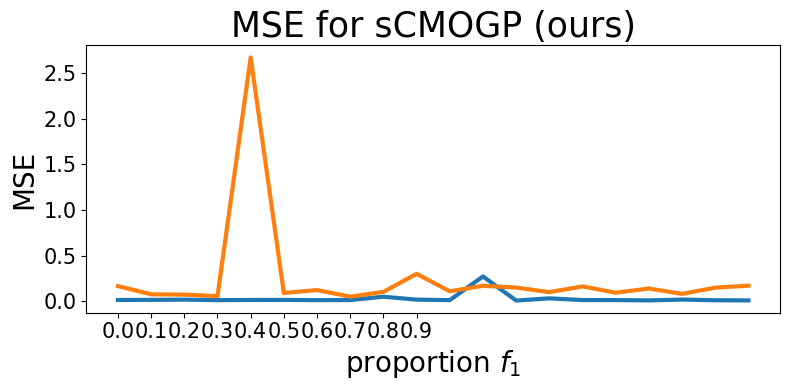

In [27]:
svgp_results = data["vgp_mse"]
cmogp_results = data["cmogp_mse"]
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(svgp_results.mean(axis=1), linewidth=3)
ax.plot(cmogp_results.mean(axis=1), linewidth=3)
ax.set_xlabel("proportion $f_1$", fontsize=20)
ax.set_xlabel("proportion $f_1$", fontsize=20)
ax.set_ylabel("MSE", fontsize=20)
ax.set_ylabel("MSE", fontsize=20)
ax.set_xticks( np.arange(0, 10, 1), np.arange(0, 1, 0.1).round(2), fontsize=15)
ax.set_xticks(np.arange(0, 10, 1), np.arange(0, 1, 0.1).round(2), fontsize=15)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.set_title("MSE for SVGP", fontsize=25)
ax.set_title("MSE for sCMOGP (ours)", fontsize=25)
plt.tight_layout()
plt.show()

In [28]:
from scipy.stats import ttest_rel, wilcoxon, normaltest
print(normaltest(cmogp_results.mean(axis=1)))
print(normaltest(svgp_results.mean(axis=1)))

print([np.format_float_positional(p) for p in wilcoxon(cmogp_results, svgp_results, axis=1).pvalue.flatten()])

NormaltestResult(statistic=50.915255822657755, pvalue=8.788053168240194e-12)
NormaltestResult(statistic=49.718245550708204, pvalue=1.5988957705492053e-11)
['0.0004493369040712341', '0.0010188290449538871', '0.0013245375247995077', '0.030365113315399057', '0.0045499278703053396', '0.00803442885556667', '0.0028208603832232753', '0.0017130176382195042', '0.0064246026289671515', '0.00021907963048002185', '0.00039023125084089363', '0.011129014082381268', '0.0001401336206158955', '0.02509350819808047', '0.0005167151238567522', '0.0004493369040712341', '0.0005934167947217433', '0.00021907963048002185', '0.0001401336206158955', '0.15195618574341052']
